# Arabic Handwritten Digit Recognition

 Sondos Qasarwa
 1210259


The goal is to build a model that can
correctly classify digits from 0 to 9 based on visual patterns extracted from handwritten samples

## Data Loading and Preparation

**Dataset Description**
The dataset consists of grayscale images of Arabic handwritten digits (0–9). Each image contains a single digit and is used for classification into one of 10 classes.

Dataset characteristics:
- Image size: 28 × 28
- Grayscale images
- 10 classes

Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Handwritten Arabic Numerals (0-9) .zip to Handwritten Arabic Numerals (0-9) .zip


Extract the dataset folder

In [3]:
import os
import zipfile

print("Current folder:", os.getcwd())
print("Files here:")
for f in os.listdir():
    print(repr(f))

zip_files = [f for f in os.listdir() if f.lower().endswith('.zip')]
print("ZIP files found:", zip_files)

zip_path = os.path.join(os.getcwd(), zip_files[0])
print("Using zip:", repr(zip_path))

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Extraction complete")
print("Extracted content:", os.listdir('dataset'))

Current folder: /content
Files here:
'.config'
'Handwritten Arabic Numerals (0-9) .zip'
'sample_data'
ZIP files found: ['Handwritten Arabic Numerals (0-9) .zip']
Using zip: '/content/Handwritten Arabic Numerals (0-9) .zip'
Extraction complete
Extracted content: ['ANGKA ARAB']


In [4]:
import os

data_dir = "dataset/ANGKA ARAB"
print(os.listdir(data_dir))

['8', '9', '2', '7', '5', '0', '6', '3', '1', '4']


Count how many images per class

In [5]:
import os

data_dir = "dataset/ANGKA ARAB"

class_counts = {}

for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith('.png')]
        class_counts[class_name] = len(image_files)

print(class_counts)
print("Total images =", sum(class_counts.values()))

for cls, count in class_counts.items():
    print(f"Digit {cls}: {count} images")

print(f"\nTotal: {sum(class_counts.values())} images")

{'0': 935, '1': 935, '2': 935, '3': 935, '4': 935, '5': 935, '6': 935, '7': 935, '8': 935, '9': 935}
Total images = 9350
Digit 0: 935 images
Digit 1: 935 images
Digit 2: 935 images
Digit 3: 935 images
Digit 4: 935 images
Digit 5: 935 images
Digit 6: 935 images
Digit 7: 935 images
Digit 8: 935 images
Digit 9: 935 images

Total: 9350 images


Visualize one sample per class

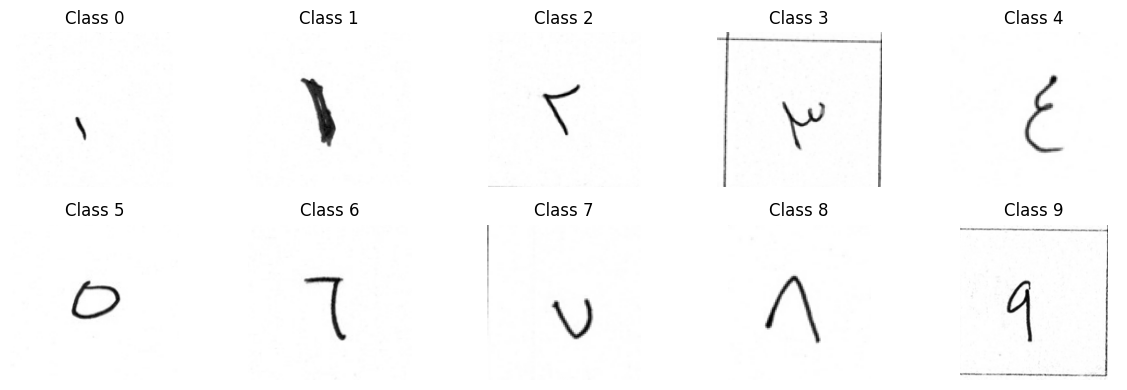

In [6]:
import os
import cv2
import matplotlib.pyplot as plt

data_dir = "dataset/ANGKA ARAB"

plt.figure(figsize=(12, 4))

for i, class_name in enumerate(sorted(os.listdir(data_dir))):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        img_name = os.listdir(class_path)[0]
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Class {class_name}")
        plt.axis("off")

plt.tight_layout()
plt.show()

**Data Preprocessing**

Before training the models, the following preprocessing steps were applied:

- Normalization of pixel values
- Train/validation/test split (70%, 15%, 15%)
- Reshaping images for CNN input

In [7]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

data_dir = "dataset/ANGKA ARAB"

X = []
y = []
bad_files = []

for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(".png"):
                img_path = os.path.join(class_path, img_name)

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # skip unreadable files
                if img is None:
                    bad_files.append(img_path)
                    continue

                img = cv2.resize(img, (28, 28))

                X.append(img)
                y.append(int(class_name))

X = np.stack(X)
y = np.array(y)

print("Loaded dataset shape:", X.shape, y.shape)
print("Unreadable files:", len(bad_files))
if len(bad_files) > 0:
    print("First bad file:", bad_files[0])

# Split: 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Split remaining into train/val so val = 15% of whole dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15 / 0.85,
    random_state=42,
    stratify=y_temp
)

# Normalize
X_train = X_train.astype("float32") / 255.0
X_val   = X_val.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# Add channel dimension for CNN
X_train = np.expand_dims(X_train, axis=-1)
X_val   = np.expand_dims(X_val, axis=-1)
X_test  = np.expand_dims(X_test, axis=-1)

print("\nShapes after split:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

def show_distribution(labels, name):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name} distribution:")
    for u, c in zip(unique, counts):
        print(f"Digit {u}: {c}")

show_distribution(y_train, "Train")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")

Loaded dataset shape: (9350, 28, 28) (9350,)
Unreadable files: 0

Shapes after split:
Train: (6544, 28, 28, 1) (6544,)
Val  : (1403, 28, 28, 1) (1403,)
Test : (1403, 28, 28, 1) (1403,)

Train distribution:
Digit 0: 655
Digit 1: 655
Digit 2: 654
Digit 3: 654
Digit 4: 654
Digit 5: 655
Digit 6: 654
Digit 7: 654
Digit 8: 655
Digit 9: 654

Validation distribution:
Digit 0: 140
Digit 1: 140
Digit 2: 141
Digit 3: 140
Digit 4: 140
Digit 5: 140
Digit 6: 140
Digit 7: 141
Digit 8: 140
Digit 9: 141

Test distribution:
Digit 0: 140
Digit 1: 140
Digit 2: 140
Digit 3: 141
Digit 4: 141
Digit 5: 140
Digit 6: 141
Digit 7: 140
Digit 8: 140
Digit 9: 140


### Images Inversion

Inverted datasets created:
Train: (6544, 28, 28, 1)
Val  : (1403, 28, 28, 1)
Test : (1403, 28, 28, 1)


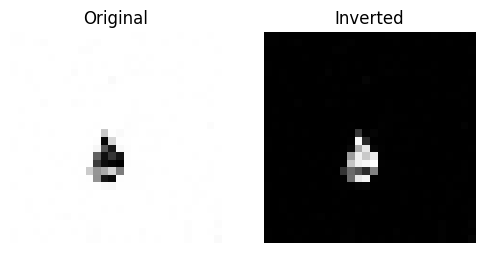

In [8]:
import matplotlib.pyplot as plt

# Create inverted versions of the datasets

X_train_inv = 1.0 - X_train
X_val_inv   = 1.0 - X_val
X_test_inv  = 1.0 - X_test

print("Inverted datasets created:")
print("Train:", X_train_inv.shape)
print("Val  :", X_val_inv.shape)
print("Test :", X_test_inv.shape)

idx = 0

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(X_train[idx].squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(X_train_inv[idx].squeeze(), cmap="gray")
plt.title("Inverted")
plt.axis("off")

plt.show()

##Classical Machine Learning Experiement

As a baseline approach, Histogram of Oriented Gradients (HOG) features were extracted from the images and used to train a Support Vector Machine (SVM) classifier.

In [63]:
from skimage.feature import hog
import numpy as np

# Remove channel dimension
X_train_cl = X_train.squeeze()
X_val_cl   = X_val.squeeze()
X_test_cl  = X_test.squeeze()

def extract_hog_features(X):
    features = []

    for img in X:
        hog_feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(4,4),
            cells_per_block=(2,2),
            block_norm='L2-Hys'
        )
        features.append(hog_feat)

    return np.array(features)

# Extract HOG features
X_train_hog = extract_hog_features(X_train_cl)
X_val_hog   = extract_hog_features(X_val_cl)
X_test_hog  = extract_hog_features(X_test_cl)

print("HOG train shape:", X_train_hog.shape)

HOG train shape: (6544, 1296)


Validation Accuracy: 0.8431931575196009
Test Accuracy: 0.8289379900213828


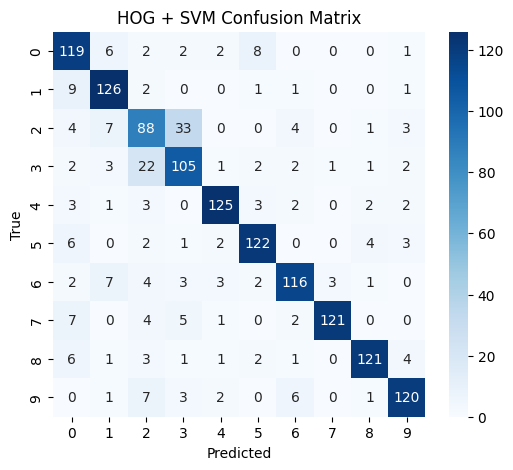

              precision    recall  f1-score   support

           0       0.75      0.85      0.80       140
           1       0.83      0.90      0.86       140
           2       0.64      0.63      0.64       140
           3       0.69      0.74      0.71       141
           4       0.91      0.89      0.90       141
           5       0.87      0.87      0.87       140
           6       0.87      0.82      0.84       141
           7       0.97      0.86      0.91       140
           8       0.92      0.86      0.89       140
           9       0.88      0.86      0.87       140

    accuracy                           0.83      1403
   macro avg       0.83      0.83      0.83      1403
weighted avg       0.83      0.83      0.83      1403



In [66]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm.fit(X_train_hog, y_train)

y_val_pred = svm.predict(X_val_hog)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

y_test_pred = svm.predict(X_test_hog)
test_acc = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", test_acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("HOG + SVM Confusion Matrix")
plt.show()

print(classification_report(y_test, y_test_pred))



##Deep Learning:  Custom CNN Models

### CNN Models Architecture

In [10]:
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers

def build_cnn_model(
    input_shape=(28, 28, 1),
    num_classes=10,
    conv_filters=[32, 64],
    kernel_size=(3, 3),
    pool_size=(2, 2),
    dense_units=128,
    activation="relu",
    use_batchnorm=False,
    dropout_rate=0.0,
    l2_reg=0.0
):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    for filters in conv_filters:
        model.add(
            layers.Conv2D(
                filters,
                kernel_size=kernel_size,
                padding="same",
                kernel_regularizer=regularizers.l2(l2_reg) if l2_reg > 0 else None
            )
        )

        if use_batchnorm:
            model.add(layers.BatchNormalization())

        model.add(layers.Activation(activation))
        model.add(layers.MaxPooling2D(pool_size=pool_size))

    model.add(layers.Flatten())

    model.add(
        layers.Dense(
            dense_units,
            activation=activation,
            kernel_regularizer=regularizers.l2(l2_reg) if l2_reg > 0 else None
        )
    )

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

In [13]:
from tensorflow.keras import models, layers, regularizers

def build_cnn_convconv_blocks(
    input_shape=(28, 28, 1),
    num_classes=10,
    block_filters=(32, 64, 128),   # 2 blocks -> (32, 64), 3 blocks -> (32, 64, 128)
    kernel_size=(3, 3),
    pool_size=(2, 2),
    dense_units=128,
    activation="relu",
    use_batchnorm=False,
    dropout_rate=0.0,
    l2_reg=0.0
):
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    for filters in block_filters:
        # Conv 1
        model.add(layers.Conv2D(filters, kernel_size, padding="same", kernel_regularizer=reg))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))

        # Conv 2
        model.add(layers.Conv2D(filters, kernel_size, padding="same", kernel_regularizer=reg))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))

        # Pool
        model.add(layers.MaxPooling2D(pool_size=pool_size))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation=activation, kernel_regularizer=reg))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

In [14]:
def get_optimizer(name, learning_rate=1e-3):
    name = name.lower()

    if name == "adam":
        return Adam(learning_rate=learning_rate)
    elif name == "sgd":
        return SGD(learning_rate=learning_rate, momentum=0.9)
    elif name == "rmsprop":
        return RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer: {name}")

In [15]:
# def compile_and_train(
#     model,
#     X_train, y_train,
#     X_val, y_val,
#     optimizer="adam",
#     learning_rate=1e-3,
#     epochs=20,
#     batch_size=32,
#     callbacks=None
# ):
#     opt = get_optimizer(optimizer, learning_rate)

#     model.compile(
#         optimizer=opt,
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )

#     start_time = time.time()

#     history = model.fit(
#         X_train, y_train,
#         validation_data=(X_val, y_val),
#         epochs=epochs,
#         batch_size=batch_size,
#         callbacks=callbacks,
#         verbose=1
#     )

#     train_time = time.time() - start_time

#     return history, train_time

import time
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def compile_and_train(
    model,
    X_train, y_train,
    X_val, y_val,
    optimizer="adam",
    learning_rate=1e-3,
    epochs=20,
    batch_size=32,
    callbacks=None,
    augmentation=False,
    augmentation_params=None
):
    opt = get_optimizer(optimizer, learning_rate)

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    if augmentation:
        if augmentation_params is None:
            augmentation_params = {
                "rotation_range": 10,
                "width_shift_range": 0.1,
                "height_shift_range": 0.1,
                "zoom_range": 0.1
            }

        train_datagen = ImageDataGenerator(**augmentation_params)
        train_datagen.fit(X_train)

        history = model.fit(
            train_datagen.flow(X_train, y_train, batch_size=batch_size),
            validation_data=(X_val, y_val),
            epochs=epochs,
            callbacks=callbacks,
            verbose=1
        )
    else:
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )

    train_time = time.time() - start_time
    return history, train_time

In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_classification_metrics(model, X, y, average="macro"):
    y_prob = model.predict(X, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    metrics = {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, average=average, zero_division=0),
        "recall": recall_score(y, y_pred, average=average, zero_division=0),
        "f1_score": f1_score(y, y_pred, average=average, zero_division=0)
    }

    return metrics, y_pred

**Run Experiment helper method**

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

all_results = []
trained_models = {}
histories = {}
experiment_rows = []

def run_experiment(
    name,
    model_fn,
    model_params,
    train_params,
    X_train, y_train,
    X_val, y_val,
    X_test=None, y_test=None,
    compute_test_metrics=False,
    average="macro"
):

    print(f"\n{'='*50}")
    print(f"Running Experiment: {name}")
    print(f"{'='*50}")

    # Build model
    model = model_fn(**model_params)

    # Callbacks
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=train_params.get("early_stop_patience", 8),
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=train_params.get("lr_patience", 3),
        min_lr=1e-6,
        verbose=1
    )

    callbacks = [early_stop, reduce_lr]

    # Train
    history, train_time = compile_and_train(
        model,
        X_train, y_train,
        X_val, y_val,
        optimizer=train_params.get("optimizer", "adam"),
        learning_rate=train_params.get("learning_rate", 1e-3),
        epochs=train_params.get("epochs", 50),
        batch_size=train_params.get("batch_size", 32),
        callbacks=callbacks,
        augmentation=train_params.get("augmentation", False),
        augmentation_params=train_params.get("augmentation_params", None)
    )

    # Validation evaluation
    val_metrics, _ = compute_classification_metrics(model, X_val, y_val, average=average)

    best_val_acc = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])

    result = {
        "name": name,
        "num_params": model.count_params(),
        "train_time": round(train_time,2),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "val_acc": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1_score"],
        "epochs_trained": len(history.history["loss"])
    }

    # Optional test evaluation
    if compute_test_metrics and X_test is not None:
        test_metrics, _ = compute_classification_metrics(model, X_test, y_test, average=average)

        result.update({
            "test_acc": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1_score"]
        })
    all_results.append(result)
    trained_models[result["name"]] = model
    histories[result["name"]] = history
    log_experiment(result)

    exps = [
        name
    ]
    print_results_table(all_results, experiment_names=exps)

    plot_metric_comparison(histories, exps, "val_accuracy",
                          "Validation Accuracy")
    plot_metric_comparison(
        histories,
        exps,
        metric="val_loss",
        title="Validation Loss"
    )

    return model, history, result

### Experiment Evaluation Utilities

In [18]:
import pandas as pd
def log_experiment(result, digits=4):
    experiment_rows = []
    row = {
        "Experiment": result["name"],
        "Val Acc": round(result["val_acc"], digits),
        "Val Precision": round(result["val_precision"], digits),
        "Val Recall": round(result["val_recall"], digits),
        "Val F1": round(result["val_f1"], digits),
        "Best Val Acc": round(result["best_val_acc"], digits),
        "Params": result["num_params"],
        "Train Time": round(result["train_time"], 2),
    }

    experiment_rows.append(row)

    df = pd.DataFrame(experiment_rows)
    display(df)

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

def print_results_table(all_results, experiment_names=None):
    df = pd.DataFrame(all_results)

    if experiment_names is not None:
        df = df[df["name"].isin(experiment_names)].copy()

    cols = [
        "name",
        "val_acc",
        "val_precision",
        "val_recall",
        "val_f1",
        "num_params",
        "train_time"
    ]

    df = df[cols].copy()

    df["val_acc"] = df["val_acc"].round(4)
    df["val_precision"] = df["val_precision"].round(4)
    df["val_recall"] = df["val_recall"].round(4)
    df["val_f1"] = df["val_f1"].round(4)
    df["train_time"] = df["train_time"].round(2)

    df = df.sort_values(by="val_acc", ascending=False)

    df.columns = [
        "Experiment",
        "Val Acc",
        "Val Precision",
        "Val Recall",
        "Val F1",
        "Params",
        "Train Time"
    ]

    display(df)
    return df


def plot_metric_comparison(histories, experiment_names, metric="val_accuracy", title=None):
    plt.figure(figsize=(7, 5))

    for name in experiment_names:
        if name in histories and metric in histories[name].history:
            plt.plot(histories[name].history[metric], label=name)

    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title if title else f"Comparison of {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_history(histories, experiment_name):
    history = histories[experiment_name]

    plt.figure(figsize=(6, 4))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{experiment_name} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## CNN Experiments

### baseline CNN experiment

In [ ]:
exp = {
    "name": "cnn_base",
    "model_fn": build_cnn_model,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "conv_filters": [32, 64],
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 20,
        "augmentation": False
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)


Running Experiment: cnn_base
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.1510 - loss: 2.2524 - val_accuracy: 0.4505 - val_loss: 1.6378 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.5460 - loss: 1.3849 - val_accuracy: 0.7085 - val_loss: 1.0074 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.7228 - loss: 0.8764 - val_accuracy: 0.8083 - val_loss: 0.6412 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.8326 - loss: 0.5464 - val_accuracy: 0.8282 - val_loss: 0.5417 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.8720 - loss: 0.4198 - val_accuracy: 0.8582 - val_loss: 0.4453 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.8906 - loss: 0.3360 - val_accuracy: 0.8831 - val_loss: 0.3795 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_base,0.9187,0.9187,0.9188,0.9185,0.9187,421642,200.39


### Baseline CNN with the inverted images

In [ ]:
exp = {
    "name": "cnn_base_inverted",
    "model_fn": build_cnn_model,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "conv_filters": [32, 64],
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 20,
        "augmentation": False
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train_inv, y_train=y_train,
    X_val=X_val_inv, y_val=y_val,
    compute_test_metrics=False
)


Running Experiment: cnn_base_inverted
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.4520 - loss: 1.6512 - val_accuracy: 0.7776 - val_loss: 0.6439 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8369 - loss: 0.5097 - val_accuracy: 0.8724 - val_loss: 0.3735 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8950 - loss: 0.3062 - val_accuracy: 0.8988 - val_loss: 0.3014 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.9299 - loss: 0.2191 - val_accuracy: 0.9031 - val_loss: 0.2726 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.9458 - loss: 0.1676 - val_accuracy: 0.9031 - val_loss: 0.2736 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.9621 - loss: 0.1199 - val_accuracy: 0.9202 - val_loss: 0.2334 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_base_inverted,0.9252,0.9277,0.9252,0.9253,0.938,421642,155.99


###Deeper CNN

In [ ]:
exp = {
    "name": "cnn_deeper",
    "model_fn": build_cnn_model,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "conv_filters": [32, 64, 128],
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 20,
        "augmentation": False
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)


Running Experiment: cnn_deeper
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.2042 - loss: 2.1361 - val_accuracy: 0.7512 - val_loss: 0.7920 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.7863 - loss: 0.6351 - val_accuracy: 0.8582 - val_loss: 0.4017 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.8850 - loss: 0.3449 - val_accuracy: 0.8831 - val_loss: 0.3177 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9125 - loss: 0.2644 - val_accuracy: 0.8988 - val_loss: 0.2660 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.9197 - loss: 0.2173 - val_accuracy: 0.9166 - val_loss: 0.2550 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.9378 - loss: 0.1788 - val_accuracy: 0.9252 - val_loss: 0.2292 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 13s 

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_deeper,0.943,0.9436,0.9431,0.9427,0.9501,241546,331.96


### CNN with Stacked Convolutions per Stage (3 Stages)

In this architecture, each stage contains two convolutional layers before the pooling operation
(Conv–Conv–Pool), allowing the network to learn more complex feature representations within each block.

In [ ]:
exp = {
    "name": "cnn_convconv",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64, 128),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 20,
        "augmentation": False
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)


Running Experiment: cnn_convconv
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 50s 206ms/step - accuracy: 0.1715 - loss: 2.1433 - val_accuracy: 0.4897 - val_loss: 1.4978 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 197ms/step - accuracy: 0.6532 - loss: 0.9815 - val_accuracy: 0.7933 - val_loss: 0.5484 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 198ms/step - accuracy: 0.8355 - loss: 0.4512 - val_accuracy: 0.8318 - val_loss: 0.4509 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 198ms/step - accuracy: 0.8803 - loss: 0.3203 - val_accuracy: 0.8817 - val_loss: 0.3074 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 200ms/step - accuracy: 0.9189 - loss: 0.2255 - val_accuracy: 0.8795 - val_loss: 0.3430 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 198ms/step - accuracy: 0.9292 - loss: 0.1982 - val_accuracy: 0.9173 - val_loss: 0.2214 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_convconv,0.9565,0.9566,0.9566,0.9565,0.9579,435306,834.69


### CNN with Stacked Convolutions per Stage (2 Stages)

In [ ]:
exp = {
    "name": "cnn_convconv_2blocks",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 20,
        "augmentation": False
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)


Running Experiment: cnn_convconv_2blocks
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 152ms/step - accuracy: 0.1416 - loss: 2.2554 - val_accuracy: 0.5560 - val_loss: 1.3460 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.6713 - loss: 0.9933 - val_accuracy: 0.8325 - val_loss: 0.5009 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.8520 - loss: 0.4241 - val_accuracy: 0.8909 - val_loss: 0.3087 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.9115 - loss: 0.2492 - val_accuracy: 0.9145 - val_loss: 0.2394 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 140ms/step - accuracy: 0.9315 - loss: 0.2061 - val_accuracy: 0.9216 - val_loss: 0.2497 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 142ms/step - accuracy: 0.9464 - loss: 0.1460 - val_accuracy: 0.9273 - val_loss: 0.2232 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_convconv_2blocks,0.9572,0.9576,0.9573,0.9573,0.9572,467818,651.19


**Comparing CNN Architectures**

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
5,cnn_convconv_2blocks,0.9572,0.9576,0.9573,0.9573,467818,651.19
3,cnn_convconv,0.9565,0.9566,0.9566,0.9565,435306,834.69
2,cnn_deeper,0.9430,0.9436,0.9431,0.9427,241546,331.96
4,cnn_base,0.9187,0.9187,0.9188,0.9185,421642,200.39


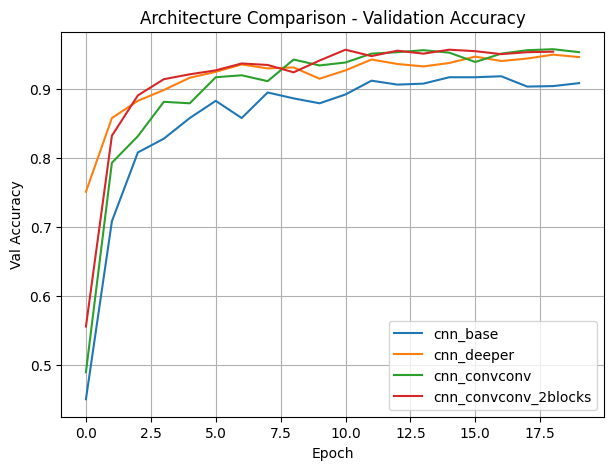

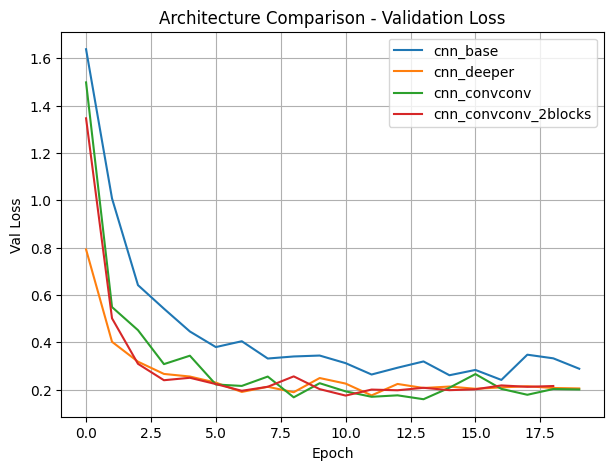

In [ ]:
arch_names = ["cnn_base", "cnn_deeper", "cnn_convconv", "cnn_convconv_2blocks"]

print_results_table(all_results, experiment_names=arch_names)

plot_metric_comparison(
    histories,
    arch_names,
    metric="val_accuracy",
    title="Architecture Comparison - Validation Accuracy"
)

plot_metric_comparison(
    histories,
    arch_names,
    metric="val_loss",
    title="Architecture Comparison - Validation Loss"
)


Running Experiment: cnn_convconv_2blocks
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 159ms/step - accuracy: 0.1362 - loss: 2.2261 - val_accuracy: 0.5973 - val_loss: 1.1783 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 146ms/step - accuracy: 0.7121 - loss: 0.8435 - val_accuracy: 0.8574 - val_loss: 0.3999 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 31s 149ms/step - accuracy: 0.8764 - loss: 0.3597 - val_accuracy: 0.8917 - val_loss: 0.3088 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 141ms/step - accuracy: 0.9209 - loss: 0.2213 - val_accuracy: 0.9130 - val_loss: 0.2448 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 42s 145ms/step - accuracy: 0.9498 - loss: 0.1521 - val_accuracy: 0.9252 - val_loss: 0.2379 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 43s 154ms/step - accuracy: 0.9539 - loss: 0.1303 - val_accuracy: 0.9266 - val_loss: 0.2287 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_convconv_2blocks,0.9501,0.951,0.9501,0.9502,0.9558,902250,674.53


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
8,cnn_convconv_2blocks,0.9501,0.951,0.9501,0.9502,902250,674.53


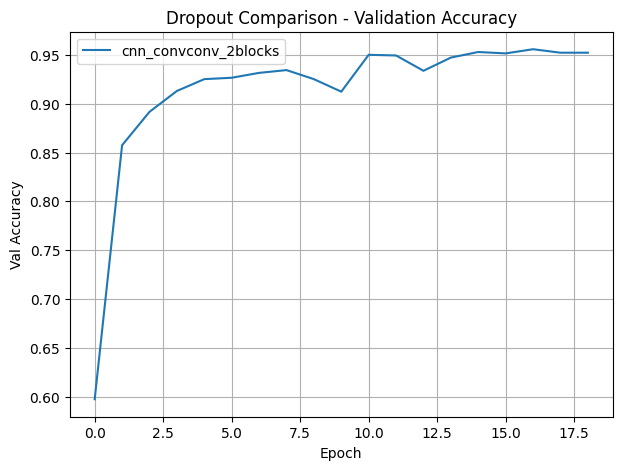

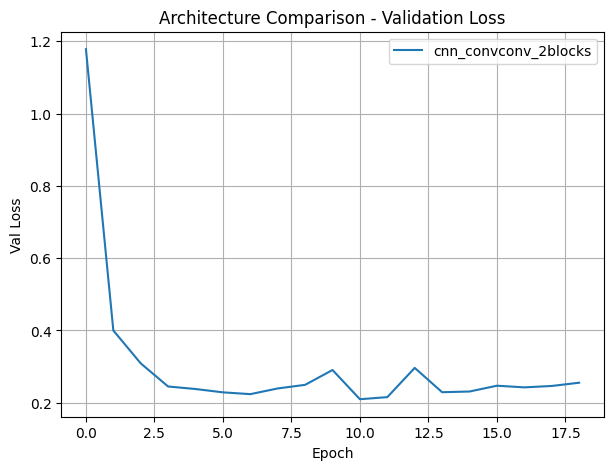

In [126]:
exp = {
    "name": "cnn_convconv_2blocks",
    "model_fn": build_cnn_convconv_2FC,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 20,
        "augmentation": False
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)

### CNN with Dropout

In [ ]:
dropout_values = [0.1, 0.25, 0.4]

for dr in dropout_values:
    exp = {
        "name": f"cnn_conv_blocks2_dropout_{str(dr).replace('.', '')}",
        "model_fn": build_cnn_convconv_blocks,
        "model_params": {
            "input_shape": (28, 28, 1),
            "num_classes": 10,
            "block_filters": (32, 64),
            "kernel_size": (3, 3),
            "pool_size": (2, 2),
            "dense_units": 128,
            "activation": "relu",
            "use_batchnorm": False,
            "dropout_rate": dr,
            "l2_reg": 0.0
        },
        "train_params": {
            "optimizer": "adam",
            "learning_rate": 1e-3,
            "batch_size": 32,
            "epochs": 20,
            "augmentation": False
        }
    }

    model, history, result = run_experiment(
        name=exp["name"],
        model_fn=exp["model_fn"],
        model_params=exp["model_params"],
        train_params=exp["train_params"],
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        compute_test_metrics=False
    )


Running Experiment: cnn_conv_blocks2_dropout_01
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 149ms/step - accuracy: 0.1950 - loss: 2.1461 - val_accuracy: 0.6543 - val_loss: 0.9642 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.7427 - loss: 0.7509 - val_accuracy: 0.8289 - val_loss: 0.4976 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - accuracy: 0.8572 - loss: 0.4204 - val_accuracy: 0.8838 - val_loss: 0.3325 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.8976 - loss: 0.2819 - val_accuracy: 0.9088 - val_loss: 0.2651 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.9219 - loss: 0.2314 - val_accuracy: 0.9223 - val_loss: 0.2117 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - accuracy: 0.9352 - loss: 0.1816 - val_accuracy: 0.9216 - val_loss: 0.2314 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_dropout_01,0.9359,0.9372,0.9359,0.936,0.9515,467818,633.61



Running Experiment: cnn_conv_blocks2_dropout_025
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 33s 144ms/step - accuracy: 0.1177 - loss: 2.2773 - val_accuracy: 0.6500 - val_loss: 1.1171 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.6972 - loss: 0.8778 - val_accuracy: 0.8482 - val_loss: 0.4401 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.8728 - loss: 0.3866 - val_accuracy: 0.9116 - val_loss: 0.2649 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.9133 - loss: 0.2594 - val_accuracy: 0.9173 - val_loss: 0.2341 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 144ms/step - accuracy: 0.9285 - loss: 0.2017 - val_accuracy: 0.9237 - val_loss: 0.2057 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 143ms/step - accuracy: 0.9443 - loss: 0.1674 - val_accuracy: 0.9073 - val_loss: 0.2719 - learning_rate: 0.0010
Epoch 7/20
205/205 ━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_dropout_025,0.9537,0.9555,0.9536,0.9537,0.9679,467818,716.93



Running Experiment: cnn_conv_blocks2_dropout_04
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 32s 147ms/step - accuracy: 0.1476 - loss: 2.2189 - val_accuracy: 0.6721 - val_loss: 0.9652 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step - accuracy: 0.7250 - loss: 0.7982 - val_accuracy: 0.8589 - val_loss: 0.4583 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - accuracy: 0.8512 - loss: 0.4242 - val_accuracy: 0.9052 - val_loss: 0.2790 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 145ms/step - accuracy: 0.9018 - loss: 0.2751 - val_accuracy: 0.9173 - val_loss: 0.2546 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 142ms/step - accuracy: 0.9219 - loss: 0.2287 - val_accuracy: 0.9259 - val_loss: 0.2216 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.9172 - loss: 0.2127 - val_accuracy: 0.9380 - val_loss: 0.1888 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_dropout_04,0.9629,0.9633,0.9629,0.963,0.9629,467818,701.0


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
8,cnn_conv_blocks2_dropout_04,0.9629,0.9633,0.9629,0.9630,467818,701.00
7,cnn_conv_blocks2_dropout_025,0.9537,0.9555,0.9536,0.9537,467818,716.93
6,cnn_conv_blocks2_dropout_01,0.9359,0.9372,0.9359,0.9360,467818,633.61


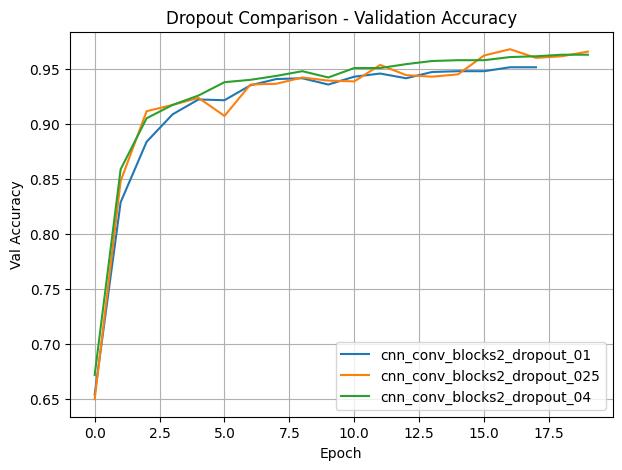

In [ ]:
dropout_exps = [
    "cnn_conv_blocks2_dropout_01",
    "cnn_conv_blocks2_dropout_025",
    "cnn_conv_blocks2_dropout_04"
]
print_results_table(all_results, experiment_names=dropout_exps)

plot_metric_comparison(histories, dropout_exps, "val_accuracy",
                       "Dropout Comparison - Validation Accuracy")

### CNN with Regularization

In [29]:
exp = {
    "name": "cnn_conv_blocks2_L2Reg",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "l2_reg": 1e-4
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 20,
        "augmentation": False,
        "augmentation_params": {
            "rotation_range": 10,
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "zoom_range": 0.1
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)


Running Experiment: cnn_conv_blocks2_L2Reg
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 32s 140ms/step - accuracy: 0.1511 - loss: 2.2490 - val_accuracy: 0.5025 - val_loss: 1.4030 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - accuracy: 0.5960 - loss: 1.1659 - val_accuracy: 0.7790 - val_loss: 0.6768 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 42s 137ms/step - accuracy: 0.8134 - loss: 0.6046 - val_accuracy: 0.8560 - val_loss: 0.4345 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 133ms/step - accuracy: 0.8877 - loss: 0.3772 - val_accuracy: 0.8717 - val_loss: 0.3719 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 42s 137ms/step - accuracy: 0.9087 - loss: 0.3022 - val_accuracy: 0.8959 - val_loss: 0.3324 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 134ms/step - accuracy: 0.9236 - loss: 0.2551 - val_accuracy: 0.9088 - val_loss: 0.3108 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_L2Reg,0.9316,0.9325,0.9316,0.9318,0.933,467818,624.2


### CNN with Batch Normalization


Running Experiment: cnn_conv_blocks2_bn
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.4834 - loss: 1.9052 - val_accuracy: 0.1005 - val_loss: 5.5277 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 177ms/step - accuracy: 0.8980 - loss: 0.3163 - val_accuracy: 0.3820 - val_loss: 2.7924 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.9404 - loss: 0.1815 - val_accuracy: 0.4526 - val_loss: 4.4009 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.9625 - loss: 0.1194 - val_accuracy: 0.3336 - val_loss: 6.2431 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 171ms/step - accuracy: 0.9668 - loss: 0.0919 - val_accuracy: 0.6771 - val_loss: 2.2680 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.9728 - loss: 0.0783 - val_accuracy: 0.1589 - val_loss: 10.7514 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_bn,0.9701,0.9709,0.97,0.9701,0.9729,468586,750.87


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
6,cnn_conv_blocks2_bn,0.9701,0.9709,0.97,0.9701,468586,750.87


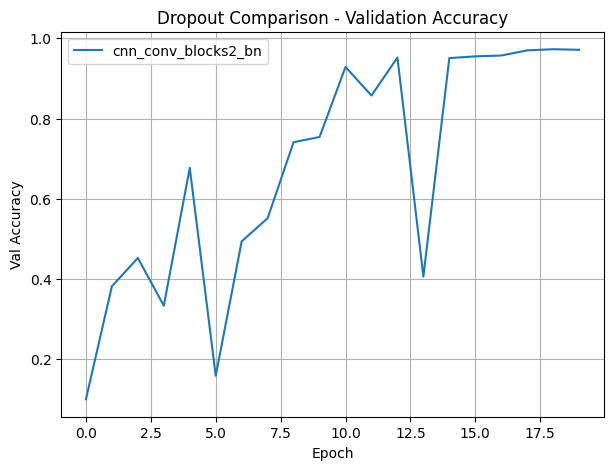

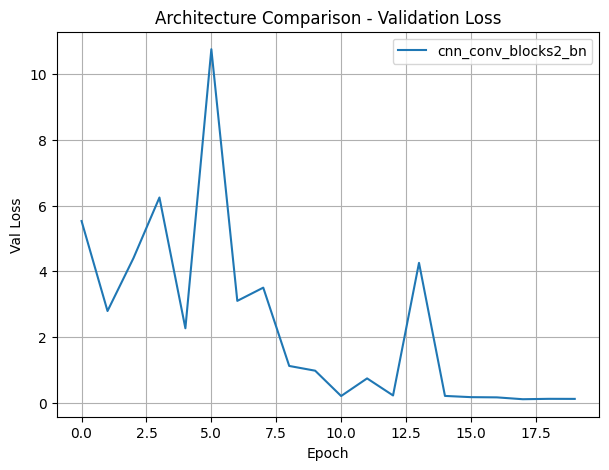

In [108]:
exp = {
    "name": "cnn_conv_blocks2_bn",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": True,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 20,
        "augmentation": False,
        "augmentation_params": {
            "rotation_range": 10,
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "zoom_range": 0.1
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)

### CNN with Augmentation

In [34]:
exp = {
    "name": "cnn_conv_blocks2_aug",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 20,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 10,
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "zoom_range": 0.1
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)


Running Experiment: cnn_conv_blocks2_aug
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.1052 - loss: 2.3035 - val_accuracy: 0.3122 - val_loss: 1.9504 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 141ms/step - accuracy: 0.4625 - loss: 1.6110 - val_accuracy: 0.8396 - val_loss: 0.4831 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 145ms/step - accuracy: 0.7811 - loss: 0.6514 - val_accuracy: 0.8724 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.8420 - loss: 0.4565 - val_accuracy: 0.9059 - val_loss: 0.2779 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 141ms/step - accuracy: 0.8655 - loss: 0.3852 - val_accuracy: 0.9102 - val_loss: 0.2363 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 31s 150ms/step - accuracy: 0.8904 - loss: 0.3334 - val_accuracy: 0.9209 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_aug,0.9622,0.9625,0.9623,0.9622,0.9622,467818,648.5


**Change number of epohcs**


Running Experiment: cnn_conv_blocks2_aug
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


205/205 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - accuracy: 0.0956 - loss: 2.3046 - val_accuracy: 0.0998 - val_loss: 2.3024 - learning_rate: 0.0010
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 140ms/step - accuracy: 0.0971 - loss: 2.3028 - val_accuracy: 0.1005 - val_loss: 2.3041 - learning_rate: 0.0010
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 140ms/step - accuracy: 0.1045 - loss: 2.2863 - val_accuracy: 0.1689 - val_loss: 2.2402 - learning_rate: 0.0010
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 31s 153ms/step - accuracy: 0.1515 - loss: 2.2240 - val_accuracy: 0.4555 - val_loss: 1.7583 - learning_rate: 0.0010
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.5121 - loss: 1.4534 - val_accuracy: 0.8418 - val_loss: 0.5249 - learning_rate: 0.0010
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 140ms/step - accuracy: 0.7880 - loss: 0.6413 - val_accuracy: 0.8824 - val_loss: 0.3716 - learning_rate: 0.0010
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 145ms/step - accuracy: 0.8364 - loss:

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_aug,0.9729,0.9736,0.9729,0.973,0.9729,467818,957.9


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
0,cnn_conv_blocks2_aug,0.9729,0.9736,0.9729,0.973,467818,957.9


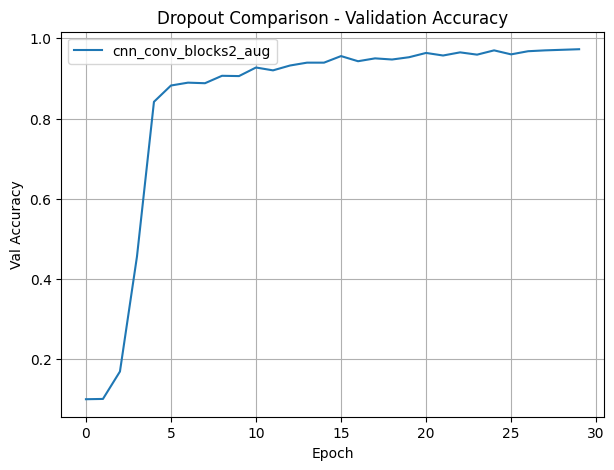

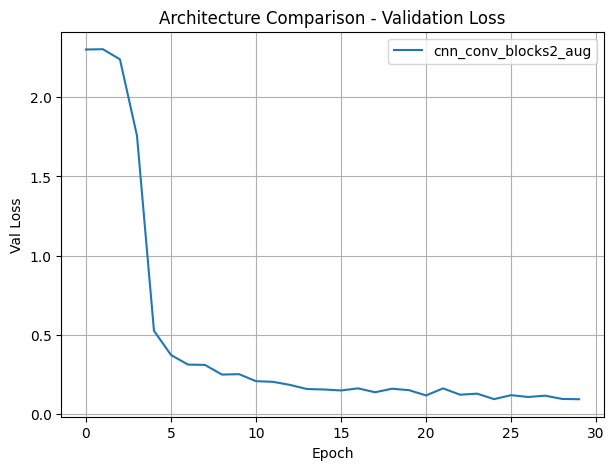

In [50]:
exp = {
    "name": "cnn_conv_blocks2_aug",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 30,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 10,
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "zoom_range": 0.1
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)

**Change Augmentation parameters**

In [36]:
exp = {
    "name": "cnn_conv_blocks2_aug2",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 20,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 8,
            "width_shift_range": 0.08,
            "height_shift_range": 0.08,
            "zoom_range": 0.05
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)


Running Experiment: cnn_conv_blocks2_aug2
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 34s 147ms/step - accuracy: 0.1035 - loss: 2.3055 - val_accuracy: 0.1140 - val_loss: 2.2932 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 141ms/step - accuracy: 0.3172 - loss: 1.9329 - val_accuracy: 0.7448 - val_loss: 0.7455 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 53s 202ms/step - accuracy: 0.7504 - loss: 0.7598 - val_accuracy: 0.8617 - val_loss: 0.4337 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 140ms/step - accuracy: 0.8452 - loss: 0.4674 - val_accuracy: 0.8810 - val_loss: 0.3724 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 140ms/step - accuracy: 0.8823 - loss: 0.3633 - val_accuracy: 0.9266 - val_loss: 0.2461 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 144ms/step - accuracy: 0.9017 - loss: 0.2965 - val_accuracy: 0.9266 - val_loss: 0.2437 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_aug2,0.9658,0.9658,0.9658,0.9657,0.9679,467818,636.44


**CNN with Augmentation and Batch Normalization**


Running Experiment: cnn_conv_blocks2_aug_bn
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


205/205 ━━━━━━━━━━━━━━━━━━━━ 99s 182ms/step - accuracy: 0.3445 - loss: 2.2310 - val_accuracy: 0.1162 - val_loss: 3.8212 - learning_rate: 0.0010
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 39s 189ms/step - accuracy: 0.8072 - loss: 0.5792 - val_accuracy: 0.3621 - val_loss: 2.7192 - learning_rate: 0.0010
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 44s 202ms/step - accuracy: 0.8734 - loss: 0.3499 - val_accuracy: 0.4198 - val_loss: 2.8607 - learning_rate: 0.0010
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 180ms/step - accuracy: 0.9060 - loss: 0.2797 - val_accuracy: 0.8346 - val_loss: 0.4717 - learning_rate: 0.0010
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 182ms/step - accuracy: 0.9115 - loss: 0.2495 - val_accuracy: 0.1525 - val_loss: 7.9587 - learning_rate: 0.0010
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - accuracy: 0.9289 - loss: 0.2140 - val_accuracy: 0.2038 - val_loss: 9.7531 - learning_rate: 0.0010
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9368 - loss: 

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_aug_bn,0.9758,0.9762,0.9758,0.9758,0.9758,468586,1253.41


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
7,cnn_conv_blocks2_aug_bn,0.9758,0.9762,0.9758,0.9758,468586,1253.41


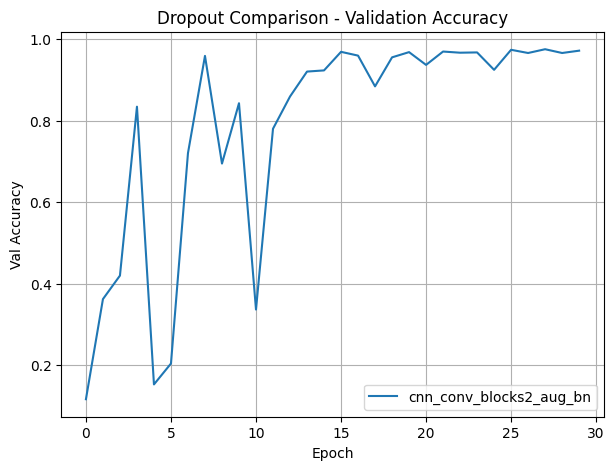

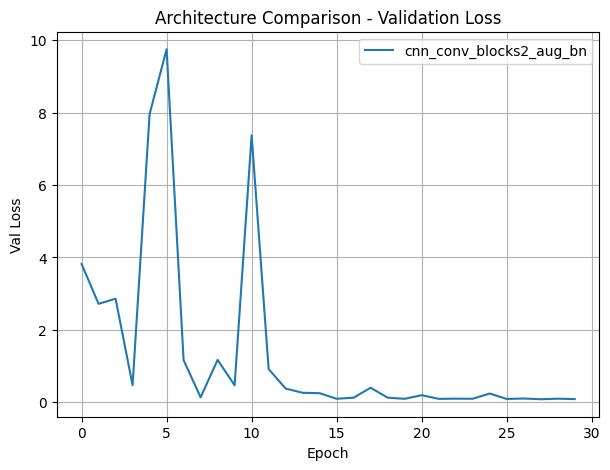

In [109]:
exp = {
    "name": "cnn_conv_blocks2_aug_bn",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": True,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 30,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 10,
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "zoom_range": 0.1
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)

In [113]:
model.evaluate(X_test,y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9805 - loss: 0.0747


[0.09025966376066208, 0.9743406772613525]


Running Experiment: cnn_conv_blocks2_aug_bn
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


205/205 ━━━━━━━━━━━━━━━━━━━━ 64s 277ms/step - accuracy: 0.3969 - loss: 1.9049 - val_accuracy: 0.0998 - val_loss: 6.3331 - learning_rate: 0.0010
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 45s 221ms/step - accuracy: 0.8338 - loss: 0.4777 - val_accuracy: 0.1454 - val_loss: 4.7575 - learning_rate: 0.0010
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 42s 203ms/step - accuracy: 0.8958 - loss: 0.3047 - val_accuracy: 0.6158 - val_loss: 1.5014 - learning_rate: 0.0010
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 39s 192ms/step - accuracy: 0.9211 - loss: 0.2365 - val_accuracy: 0.6144 - val_loss: 1.3749 - learning_rate: 0.0010
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 182ms/step - accuracy: 0.9314 - loss: 0.2037 - val_accuracy: 0.3735 - val_loss: 9.6520 - learning_rate: 0.0010
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.9455 - loss: 0.1523 - val_accuracy: 0.5075 - val_loss: 4.5974 - learning_rate: 0.0010
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9464 - loss: 

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_aug_bn,0.98,0.9806,0.98,0.9802,0.98,468586,1325.98


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
1,cnn_conv_blocks2_aug_bn,0.98,0.9806,0.98,0.9802,468586,1325.98


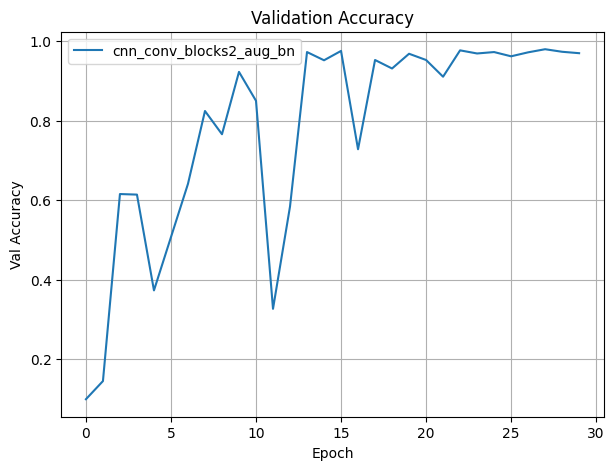

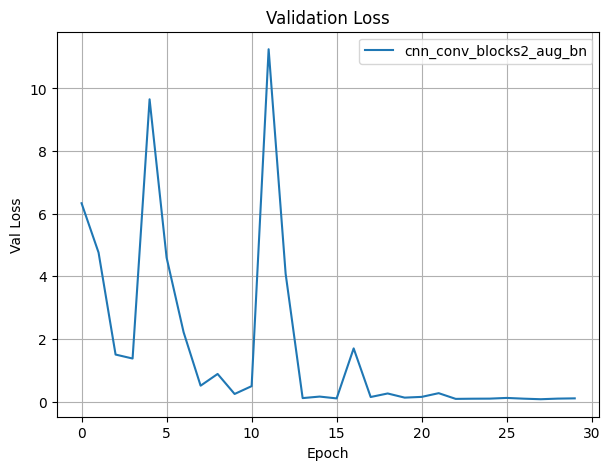

In [26]:
exp = {
    "name": "cnn_conv_blocks2_aug_bn",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": True,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 30,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 10,
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "zoom_range": 0.1
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train_inv, y_train=y_train,
    X_val=X_val_inv, y_val=y_val,
    compute_test_metrics=False
)


Running Experiment: cnn_conv_blocks2_aug_bn_inv
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


205/205 ━━━━━━━━━━━━━━━━━━━━ 44s 185ms/step - accuracy: 0.2939 - loss: 2.1304 - val_accuracy: 0.0998 - val_loss: 2.7963 - learning_rate: 1.0000e-04
Epoch 2/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 56s 273ms/step - accuracy: 0.6944 - loss: 0.9996 - val_accuracy: 0.2559 - val_loss: 1.9265 - learning_rate: 1.0000e-04
Epoch 3/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 201ms/step - accuracy: 0.7942 - loss: 0.6745 - val_accuracy: 0.8446 - val_loss: 0.4830 - learning_rate: 1.0000e-04
Epoch 4/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 48s 235ms/step - accuracy: 0.8424 - loss: 0.4888 - val_accuracy: 0.8824 - val_loss: 0.3536 - learning_rate: 1.0000e-04
Epoch 5/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 178ms/step - accuracy: 0.8598 - loss: 0.4257 - val_accuracy: 0.9244 - val_loss: 0.2257 - learning_rate: 1.0000e-04
Epoch 6/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 186ms/step - accuracy: 0.8911 - loss: 0.3395 - val_accuracy: 0.9088 - val_loss: 0.2578 - learning_rate: 1.0000e-04
Epoch 7/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 185ms/step - 

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_aug_bn_inv,0.9736,0.9748,0.9736,0.9739,0.9736,468586,1275.37


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
3,cnn_conv_blocks2_aug_bn_inv,0.9736,0.9748,0.9736,0.9739,468586,1275.37
2,cnn_conv_blocks2_aug_bn_inv,0.9665,0.9669,0.9665,0.9665,468586,1337.05


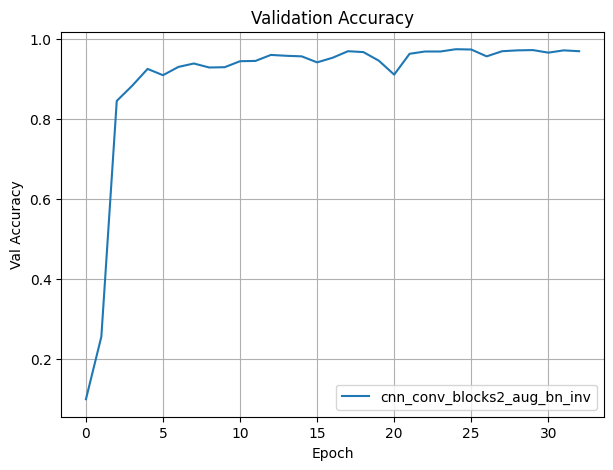

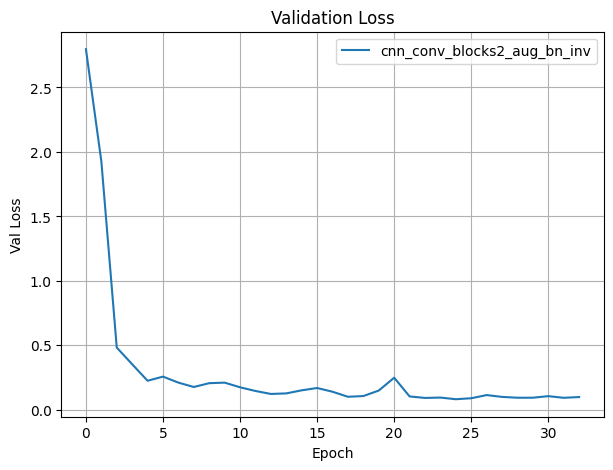

In [34]:
exp = {
    "name": "cnn_conv_blocks2_aug_bn_inv",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": True,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-4,
        "batch_size": 32,
        "epochs": 40,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 10,
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "zoom_range": 0.1
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train_inv, y_train=y_train,
    X_val=X_val_inv, y_val=y_val,
    compute_test_metrics=False
)

In [36]:
model.evaluate(X_test_inv,y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9789 - loss: 0.0648


[0.0792827159166336, 0.9743406772613525]

**Same Exp with Chnaging learning rate**


Running Experiment: cnn_conv_blocks2_aug_bn_2
Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 39s 176ms/step - accuracy: 0.2248 - loss: 2.2865 - val_accuracy: 0.1019 - val_loss: 2.3319 - learning_rate: 1.0000e-04
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.5754 - loss: 1.3463 - val_accuracy: 0.3521 - val_loss: 1.5996 - learning_rate: 1.0000e-04
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 44s 188ms/step - accuracy: 0.7453 - loss: 0.8159 - val_accuracy: 0.8475 - val_loss: 0.5264 - learning_rate: 1.0000e-04
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.8067 - loss: 0.6011 - val_accuracy: 0.8567 - val_loss: 0.4688 - learning_rate: 1.0000e-04
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 43s 180ms/step - accuracy: 0.8600 - loss: 0.4596 - val_accuracy: 0.5773 - val_loss: 1.2729 - learning_rate: 1.0000e-04
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 178ms/step - accuracy: 0.8746 - loss: 0.3845 - val_accuracy: 0.8667 - val_loss: 0.4063 - learning_rate: 1.0000e-04

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_aug_bn_2,0.9651,0.9658,0.9651,0.9652,0.9651,468586,1273.85


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
0,cnn_conv_blocks2_aug_bn_2,0.9651,0.9658,0.9651,0.9652,468586,1273.85


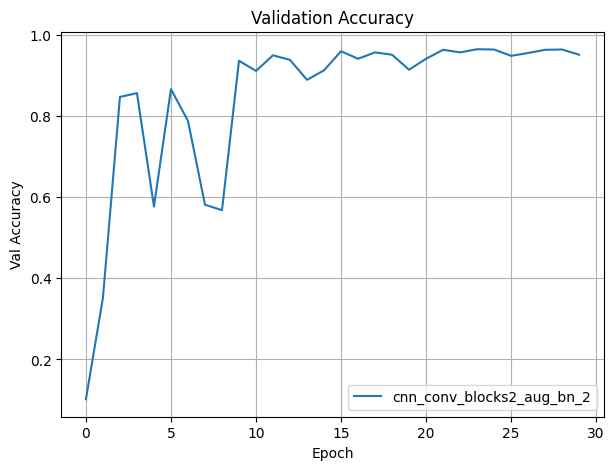

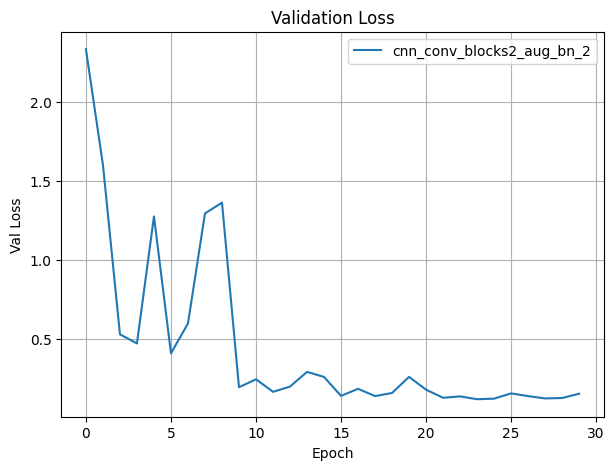

In [24]:
exp = {
    "name": "cnn_conv_blocks2_aug_bn_2",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": True,
        "dropout_rate": 0.0,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-4,
        "batch_size": 32,
        "epochs": 30,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 10,
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "zoom_range": 0.1
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)

**CNN with Augmentation and Dropout**


Running Experiment: cnn_conv_blocks2_aug_dropout
Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 45s 186ms/step - accuracy: 0.1698 - loss: 2.4293 - val_accuracy: 0.1019 - val_loss: 2.2946 - learning_rate: 0.0010
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 184ms/step - accuracy: 0.4110 - loss: 1.5729 - val_accuracy: 0.7840 - val_loss: 1.0959 - learning_rate: 0.0010
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 39s 188ms/step - accuracy: 0.6057 - loss: 1.0715 - val_accuracy: 0.6287 - val_loss: 1.2129 - learning_rate: 0.0010
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 185ms/step - accuracy: 0.7203 - loss: 0.7487 - val_accuracy: 0.5403 - val_loss: 1.4189 - learning_rate: 0.0010
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 177ms/step - accuracy: 0.7669 - loss: 0.6196 - val_accuracy: 0.7006 - val_loss: 0.9275 - learning_rate: 0.0010
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - accuracy: 0.7914 - loss: 0.5581 - val_accuracy: 0.8168 - val_loss: 0.5181 - learning_rate: 0.0010
Epoch 7/30
205/205 ━

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_aug_dropout,0.9629,0.9641,0.9629,0.9631,0.9679,468586,1165.65


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
1,cnn_conv_blocks2_aug_dropout,0.9629,0.9641,0.9629,0.9631,468586,1165.65


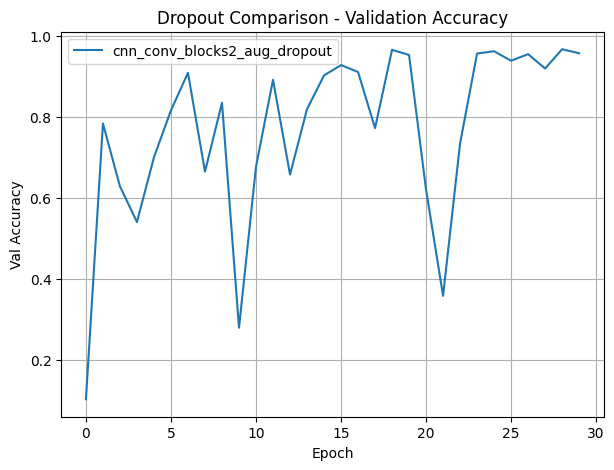

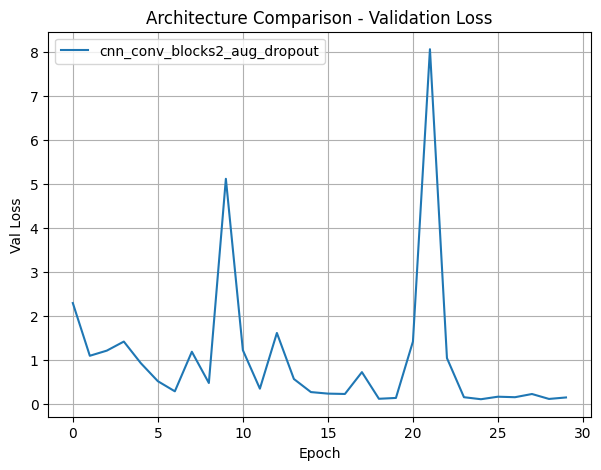

In [52]:
exp = {
    "name": "cnn_conv_blocks2_aug_dropout",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": True,
        "dropout_rate": 0.40,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 30,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 10,
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "zoom_range": 0.1
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)

**CNN + dropout + batch normlaization + augmentation**


Running Experiment: cnn_conv_blocks2_dropout_bn_aug_1
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


205/205 ━━━━━━━━━━━━━━━━━━━━ 45s 184ms/step - accuracy: 0.1185 - loss: 2.5390 - val_accuracy: 0.1005 - val_loss: 2.3026 - learning_rate: 0.0010
Epoch 2/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 188ms/step - accuracy: 0.1962 - loss: 2.1008 - val_accuracy: 0.2188 - val_loss: 2.1479 - learning_rate: 0.0010
Epoch 3/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 193ms/step - accuracy: 0.2348 - loss: 1.9931 - val_accuracy: 0.3785 - val_loss: 1.8746 - learning_rate: 0.0010
Epoch 4/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 184ms/step - accuracy: 0.2807 - loss: 1.8843 - val_accuracy: 0.1632 - val_loss: 3.0961 - learning_rate: 0.0010
Epoch 5/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 177ms/step - accuracy: 0.4737 - loss: 1.4620 - val_accuracy: 0.3293 - val_loss: 2.9326 - learning_rate: 0.0010
Epoch 6/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6159 - loss: 1.0434
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 182ms/step - accuracy: 0.6160 - loss: 1

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_dropout_bn_aug_1,0.9686,0.9695,0.9686,0.9688,0.9686,468586,1334.2


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
5,cnn_conv_blocks2_dropout_bn_aug_1,0.9686,0.9695,0.9686,0.9688,468586,1334.2


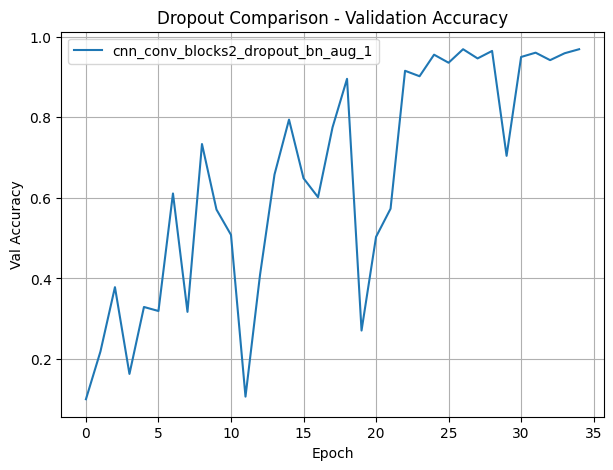

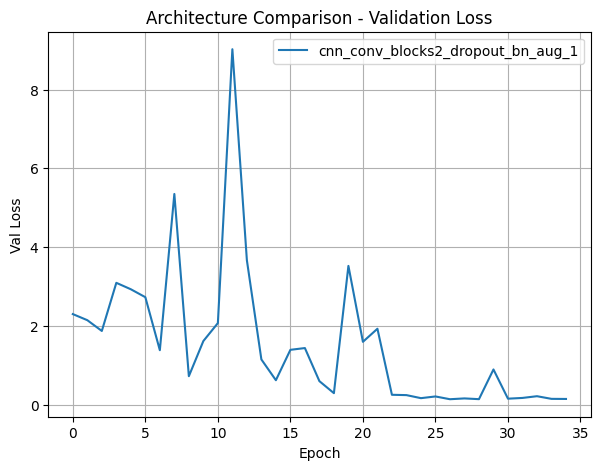

In [70]:
exp = {
    "name": "cnn_conv_blocks2_dropout_bn_aug_1",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": True,
        "dropout_rate": 0.4,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "epochs": 40,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 8,
            "width_shift_range": 0.08,
            "height_shift_range": 0.08,
            "zoom_range": 0.05
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)

**Compare some experiments**

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
8,cnn_conv_blocks2_bn,0.9729,0.9735,0.9729,0.9730,468586,735.56
9,cnn_conv_blocks2_aug,0.9622,0.9625,0.9623,0.9622,467818,648.50
7,cnn_conv_blocks2_L2Reg,0.9316,0.9325,0.9316,0.9318,467818,624.20


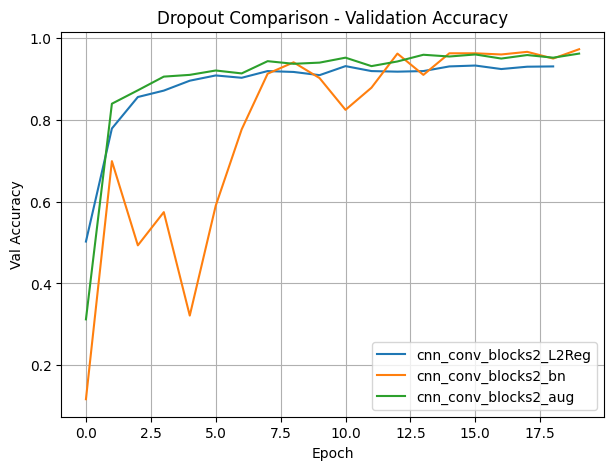

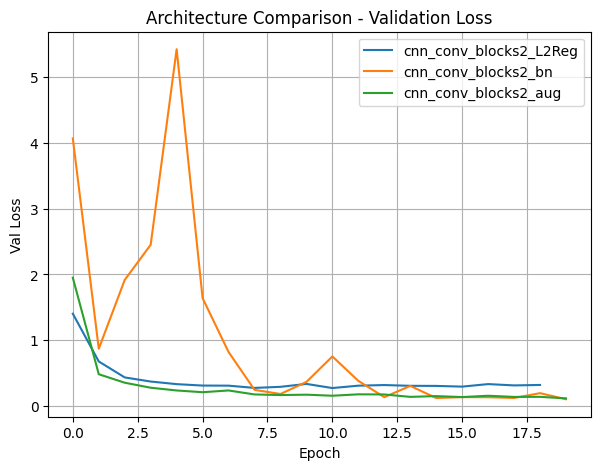

In [47]:
# exps = [
#     "cnn_conv_blocks2_dropout_04",
#     "cnn_conv_blocks2_L2Reg",
#     "cnn_conv_blocks2_bn",
#     "cnn_conv_blocks2_aug",
#     "cnn_conv_blocks2_dropout_bn_aug"

# ]

exps = [
    "cnn_conv_blocks2_dropout_04",
    "cnn_conv_blocks2_L2Reg",
    "cnn_conv_blocks2_bn",
    "cnn_conv_blocks2_aug"

]
print_results_table(all_results, experiment_names=exps)

plot_metric_comparison(histories, exps, "val_accuracy",
                       "Dropout Comparison - Validation Accuracy")
plot_metric_comparison(
    histories,
    exps,
    metric="val_loss",
    title="Architecture Comparison - Validation Loss"
)


**change batch size and learning rate**


Running Experiment: cnn_conv_blocks2_dropout_bn_aug


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 52s 386ms/step - accuracy: 0.1537 - loss: 2.6738 - val_accuracy: 0.0998 - val_loss: 2.4170 - learning_rate: 0.0010
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 37s 345ms/step - accuracy: 0.3524 - loss: 1.7170 - val_accuracy: 0.0998 - val_loss: 3.0751 - learning_rate: 0.0010
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 36s 354ms/step - accuracy: 0.5020 - loss: 1.2599 - val_accuracy: 0.2687 - val_loss: 2.1082 - learning_rate: 0.0010
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 34s 333ms/step - accuracy: 0.6226 - loss: 0.9618 - val_accuracy: 0.5538 - val_loss: 1.1385 - learning_rate: 0.0010
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 36s 349ms/step - accuracy: 0.6903 - loss: 0.7724 - val_accuracy: 0.7320 - val_loss: 0.7563 - learning_rate: 0.0010
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 37s 355ms/step - accuracy: 0.7303 - loss: 0.6808 - val_accuracy: 0.3984 - val_loss: 2.1535 - learning_rate: 0.0010
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 34s 335ms/step - accuracy: 0.7

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_dropout_bn_aug,0.9287,0.9378,0.9289,0.9268,0.948,468586,1089.74


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
2,cnn_conv_blocks2_dropout_bn_aug,0.9287,0.9378,0.9289,0.9268,468586,1089.74


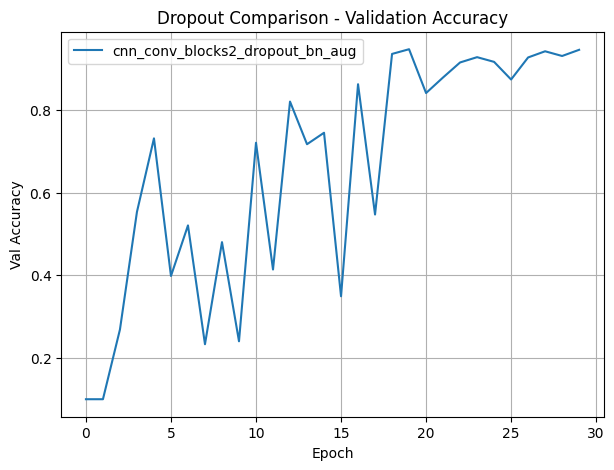

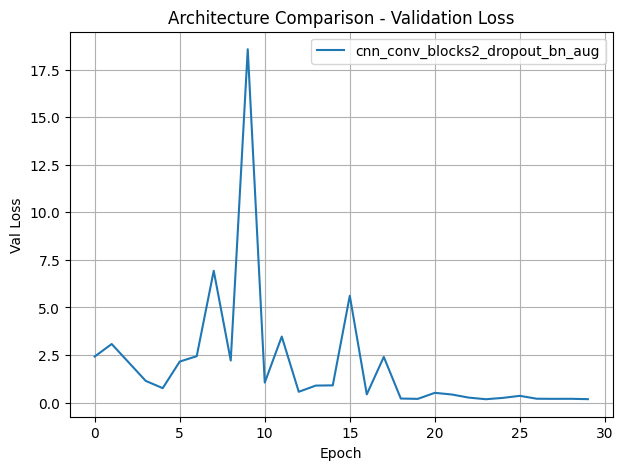

In [55]:
exp = {
    "name": "cnn_conv_blocks2_dropout_bn_aug",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": True,
        "dropout_rate": 0.4,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "batch_size": 64,
        "epochs": 30,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 8,
            "width_shift_range": 0.08,
            "height_shift_range": 0.08,
            "zoom_range": 0.05
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)


Running Experiment: cnn_conv_blocks2_dropout_bn_aug_lr4
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


205/205 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - accuracy: 0.1846 - loss: 2.3648 - val_accuracy: 0.1504 - val_loss: 2.2846 - learning_rate: 1.0000e-04
Epoch 2/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 180ms/step - accuracy: 0.4256 - loss: 1.6570 - val_accuracy: 0.5638 - val_loss: 1.5598 - learning_rate: 1.0000e-04
Epoch 3/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - accuracy: 0.6168 - loss: 1.1579 - val_accuracy: 0.7947 - val_loss: 0.7365 - learning_rate: 1.0000e-04
Epoch 4/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 179ms/step - accuracy: 0.7208 - loss: 0.8536 - val_accuracy: 0.8453 - val_loss: 0.5195 - learning_rate: 1.0000e-04
Epoch 5/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.7659 - loss: 0.7074 - val_accuracy: 0.8603 - val_loss: 0.4401 - learning_rate: 1.0000e-04
Epoch 6/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 185ms/step - accuracy: 0.7995 - loss: 0.6050 - val_accuracy: 0.8368 - val_loss: 0.5309 - learning_rate: 1.0000e-04
Epoch 7/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 39s 190ms/step - 

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Best Val Acc,Params,Train Time
0,cnn_conv_blocks2_dropout_bn_aug_lr4,0.9686,0.9691,0.9686,0.9688,0.9694,468586,1517.26


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
3,cnn_conv_blocks2_dropout_bn_aug_lr4,0.9708,0.9709,0.9708,0.9708,468586,1142.85
4,cnn_conv_blocks2_dropout_bn_aug_lr4,0.9686,0.9691,0.9686,0.9688,468586,1517.26


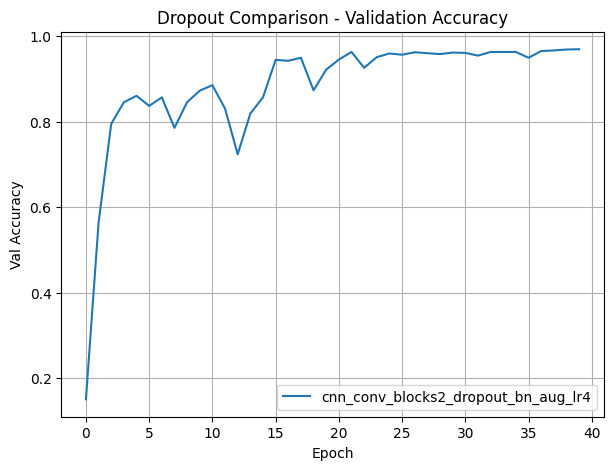

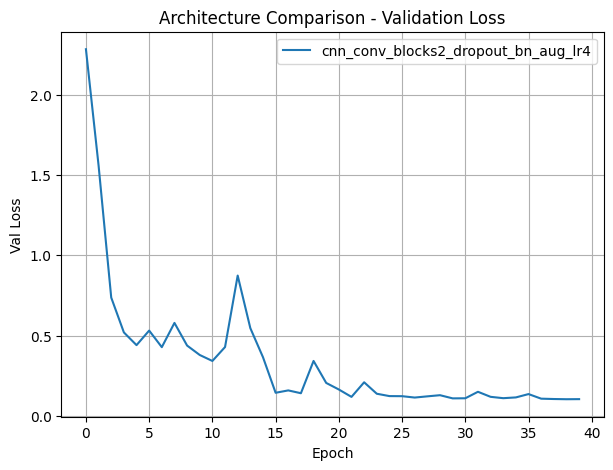

In [60]:
exp = {
    "name": "cnn_conv_blocks2_dropout_bn_aug_lr4",
    "model_fn": build_cnn_convconv_blocks,
    "model_params": {
        "input_shape": (28, 28, 1),
        "num_classes": 10,
        "block_filters": (32, 64),
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": 128,
        "activation": "relu",
        "use_batchnorm": True,
        "dropout_rate": 0.4,
        "l2_reg": 0.0
    },
    "train_params": {
        "optimizer": "adam",
        "learning_rate": 1e-4,
        "batch_size": 32,
        "epochs": 40,
        "augmentation": True,
        "augmentation_params": {
            "rotation_range": 8,
            "width_shift_range": 0.08,
            "height_shift_range": 0.08,
            "zoom_range": 0.05
        }
    }
}

model, history, result = run_experiment(
    name=exp["name"],
    model_fn=exp["model_fn"],
    model_params=exp["model_params"],
    train_params=exp["train_params"],
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    compute_test_metrics=False
)

In [68]:
for r in all_results:
    print(r["name"])

cnn_conv_blocks2_aug
cnn_conv_blocks2_aug_dropout
cnn_conv_blocks2_dropout_bn_aug
cnn_conv_blocks2_dropout_bn_aug_lr4
cnn_conv_blocks2_dropout_bn_aug_lr4


In [73]:
exps = [r["name"] for r in all_results]

print_results_table(all_results, experiment_names=exps)

,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
0,cnn_conv_blocks2_aug,0.9729,0.9736,0.9729,0.9730,467818,957.90
3,cnn_conv_blocks2_dropout_bn_aug_lr4,0.9708,0.9709,0.9708,0.9708,468586,1142.85
5,cnn_conv_blocks2_dropout_bn_aug_1,0.9686,0.9695,0.9686,0.9688,468586,1334.20
4,cnn_conv_blocks2_dropout_bn_aug_lr4,0.9686,0.9691,0.9686,0.9688,468586,1517.26
1,cnn_conv_blocks2_aug_dropout,0.9629,0.9641,0.9629,0.9631,468586,1165.65
2,cnn_conv_blocks2_dropout_bn_aug,0.9287,0.9378,0.9289,0.9268,468586,1089.74


,Experiment,Val Acc,Val Precision,Val Recall,Val F1,Params,Train Time
0,cnn_conv_blocks2_aug,0.9729,0.9736,0.9729,0.9730,467818,957.90
3,cnn_conv_blocks2_dropout_bn_aug_lr4,0.9708,0.9709,0.9708,0.9708,468586,1142.85
5,cnn_conv_blocks2_dropout_bn_aug_1,0.9686,0.9695,0.9686,0.9688,468586,1334.20
4,cnn_conv_blocks2_dropout_bn_aug_lr4,0.9686,0.9691,0.9686,0.9688,468586,1517.26
1,cnn_conv_blocks2_aug_dropout,0.9629,0.9641,0.9629,0.9631,468586,1165.65
2,cnn_conv_blocks2_dropout_bn_aug,0.9287,0.9378,0.9289,0.9268,468586,1089.74


### Best CNN Model

The best model is chosen based on the jigher validation accuarcy and evaluated on the test set.

In [38]:
import matplotlib.pyplot as plt

def plot_history(history, title="Model"):
    plt.figure(figsize=(6, 4))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9765 - loss: 0.0618
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.9765 - loss: 0.0618
Test Loss     : 0.0746
Test Accuracy : 0.9729
Test Precision: 0.9735
Test Recall   : 0.9729
Test F1       : 0.9729


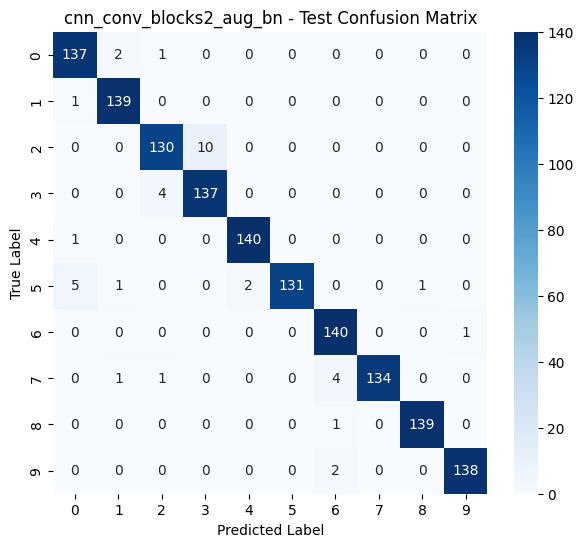

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score

best_name = "cnn_conv_blocks2_aug_bn"
best_model = trained_models[best_name]
best_history = histories[best_name]

# Test loss and accuracy from Keras evaluate
test_loss, test_acc = best_model.evaluate(X_test_inv, y_test)
best_model.evaluate(X_test_inv, y_test)
# Predictions for sklearn metrics
y_prob = best_model.predict(X_test_inv, verbose=0)
y_pred = np.argmax(y_prob, axis=1)


test_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
test_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
test_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_acc, 4))
print("Test Precision:", round(test_precision, 4))
print("Test Recall   :", round(test_recall, 4))
print("Test F1       :", round(test_f1, 4))

plot_confusion_matrix(y_test, y_pred, title=f"{best_name} - Test Confusion Matrix")


**Show missclassified examples for error analysis**

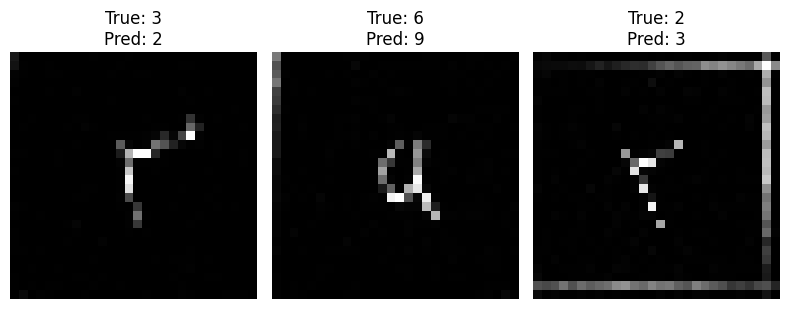

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# Find indices of misclassified samples
wrong_idx = np.where(y_test != y_pred)[0]

# Select a few examples (e.g., 3)
num_examples = 3
examples = wrong_idx[:num_examples]

plt.figure(figsize=(8,3))

for i, idx in enumerate(examples):
    plt.subplot(1, num_examples, i+1)
    plt.imshow(X_test_inv[idx].squeeze(), cmap="gray")
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Transfer Learning Experiement

In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "mobilenetv2_best.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]


In [48]:
import tensorflow as tf
import numpy as np

def prepare_for_tl(X_small, target_size=(96, 96)):
    # X_small expected shape: (N, 28, 28, 1), values in [0,1]
    X_tl = X_small.astype("float32").copy()

    # convert from [0,1] to [0,255]
    X_tl = X_tl * 255.0

    # resize
    X_tl = tf.image.resize(X_tl, target_size).numpy()

    # convert 1 channel -> 3 channels
    X_tl = np.repeat(X_tl, 3, axis=-1)

    return X_tl.astype("float32")

In [49]:
X_train_tl = prepare_for_tl(X_train)
X_val_tl   = prepare_for_tl(X_val)
X_test_tl  = prepare_for_tl(X_test)

print("TL shapes:")
print(X_train_tl.shape, X_val_tl.shape, X_test_tl.shape)

print("TL range:")
print(X_train_tl.min(), X_train_tl.max())

TL shapes:
(6544, 96, 96, 3) (1403, 96, 96, 3) (1403, 96, 96, 3)
TL range:
6.907957 255.0


In [50]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_mobilenetv2_transfer(
    input_shape=(96, 96, 3),
    num_classes=10,
    dropout_rate=0.2,
    trainable_backbone=False
):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = trainable_backbone

    inputs = layers.Input(shape=input_shape)
    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model, base_model

In [51]:
model, base_model = build_mobilenetv2_transfer(
    input_shape=(96, 96, 3),
    num_classes=10,
    dropout_rate=0.2,
    trainable_backbone=False
)

history, train_time = compile_and_train(
    model,
    X_train_tl, y_train,
    X_val_tl, y_val,
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    augmentation=False
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.6193 - loss: 1.1420
Epoch 1: val_accuracy improved from -inf to 0.87598, saving model to mobilenetv2_best.h5


205/205 ━━━━━━━━━━━━━━━━━━━━ 60s 264ms/step - accuracy: 0.6200 - loss: 1.1399 - val_accuracy: 0.8760 - val_loss: 0.3781 - learning_rate: 0.0010
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8744 - loss: 0.3501
Epoch 2: val_accuracy improved from 0.87598 to 0.89451, saving model to mobilenetv2_best.h5


205/205 ━━━━━━━━━━━━━━━━━━━━ 53s 258ms/step - accuracy: 0.8744 - loss: 0.3500 - val_accuracy: 0.8945 - val_loss: 0.2973 - learning_rate: 0.0010
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9015 - loss: 0.2778
Epoch 3: val_accuracy improved from 0.89451 to 0.89879, saving model to mobilenetv2_best.h5


205/205 ━━━━━━━━━━━━━━━━━━━━ 86s 277ms/step - accuracy: 0.9015 - loss: 0.2777 - val_accuracy: 0.8988 - val_loss: 0.2805 - learning_rate: 0.0010
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9085 - loss: 0.2551
Epoch 4: val_accuracy improved from 0.89879 to 0.90805, saving model to mobilenetv2_best.h5


205/205 ━━━━━━━━━━━━━━━━━━━━ 53s 258ms/step - accuracy: 0.9085 - loss: 0.2551 - val_accuracy: 0.9081 - val_loss: 0.2526 - learning_rate: 0.0010
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9158 - loss: 0.2268
Epoch 5: val_accuracy did not improve from 0.90805
205/205 ━━━━━━━━━━━━━━━━━━━━ 49s 240ms/step - accuracy: 0.9158 - loss: 0.2268 - val_accuracy: 0.8988 - val_loss: 0.2694 - learning_rate: 0.0010
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9225 - loss: 0.2069
Epoch 6: val_accuracy improved from 0.90805 to 0.91518, saving model to mobilenetv2_best.h5


205/205 ━━━━━━━━━━━━━━━━━━━━ 53s 257ms/step - accuracy: 0.9225 - loss: 0.2069 - val_accuracy: 0.9152 - val_loss: 0.2329 - learning_rate: 0.0010
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9320 - loss: 0.1922
Epoch 7: val_accuracy did not improve from 0.91518
205/205 ━━━━━━━━━━━━━━━━━━━━ 50s 245ms/step - accuracy: 0.9320 - loss: 0.1922 - val_accuracy: 0.9138 - val_loss: 0.2357 - learning_rate: 0.0010
Epoch 8/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9399 - loss: 0.1708
Epoch 8: val_accuracy did not improve from 0.91518
205/205 ━━━━━━━━━━━━━━━━━━━━ 52s 254ms/step - accuracy: 0.9399 - loss: 0.1709 - val_accuracy: 0.9145 - val_loss: 0.2262 - learning_rate: 0.0010
Epoch 9/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9384 - loss: 0.1672
Epoch 9: val_accuracy did not improve from 0.91518
205/205 ━━━━━━━━━━━━━━━━━━━━ 82s 257ms/step - accuracy: 0.9384 - loss: 0.1672 - val_accuracy: 0.9130 - val_loss: 0.2337 - learning_rate: 0.0010
Epoch 1

205/205 ━━━━━━━━━━━━━━━━━━━━ 53s 257ms/step - accuracy: 0.9476 - loss: 0.1530 - val_accuracy: 0.9173 - val_loss: 0.2375 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.


In [52]:
model.evaluate(X_val_tl, y_val)

44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step - accuracy: 0.9050 - loss: 0.2351


[0.22615967690944672, 0.9144690036773682]

In [54]:
model.evaluate(X_test_tl, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.9205 - loss: 0.2209


[0.2275303602218628, 0.9244475960731506]

In [55]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# unfreeze backbone
base_model.trainable = True

# freeze most layers, unfreeze only last 25
for layer in base_model.layers[:-25]:
    layer.trainable = False

# keep BatchNorm frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [57]:
history_ft, train_time_ft = compile_and_train(
    model,
    X_train_tl, y_train,
    X_val_tl, y_val,
    optimizer="adam",
    learning_rate=1e-5,
    epochs=8,
    batch_size=32,
    callbacks=callbacks,
    augmentation=False
)

Epoch 1/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9810 - loss: 0.0647
Epoch 1: val_accuracy did not improve from 0.93942
205/205 ━━━━━━━━━━━━━━━━━━━━ 83s 376ms/step - accuracy: 0.9810 - loss: 0.0647 - val_accuracy: 0.9380 - val_loss: 0.1969 - learning_rate: 1.0000e-05
Epoch 2/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9820 - loss: 0.0551
Epoch 2: val_accuracy did not improve from 0.93942
205/205 ━━━━━━━━━━━━━━━━━━━━ 72s 352ms/step - accuracy: 0.9820 - loss: 0.0551 - val_accuracy: 0.9366 - val_loss: 0.2176 - learning_rate: 1.0000e-05
Epoch 3/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9857 - loss: 0.0474
Epoch 3: val_accuracy did not improve from 0.93942
205/205 ━━━━━━━━━━━━━━━━━━━━ 82s 353ms/step - accuracy: 0.9857 - loss: 0.0474 - val_accuracy: 0.9380 - val_loss: 0.1989 - learning_rate: 1.0000e-05
Epoch 4/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9866 - loss: 0.0399
Epoch 4: val_accuracy improved from 0.93942 to 0.94084,

205/205 ━━━━━━━━━━━━━━━━━━━━ 72s 351ms/step - accuracy: 0.9866 - loss: 0.0399 - val_accuracy: 0.9408 - val_loss: 0.1910 - learning_rate: 1.0000e-05
Epoch 5/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.9902 - loss: 0.0338
Epoch 5: val_accuracy did not improve from 0.94084
205/205 ━━━━━━━━━━━━━━━━━━━━ 71s 345ms/step - accuracy: 0.9902 - loss: 0.0338 - val_accuracy: 0.9408 - val_loss: 0.1892 - learning_rate: 1.0000e-05
Epoch 6/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9896 - loss: 0.0335
Epoch 6: val_accuracy did not improve from 0.94084
205/205 ━━━━━━━━━━━━━━━━━━━━ 72s 349ms/step - accuracy: 0.9896 - loss: 0.0335 - val_accuracy: 0.9394 - val_loss: 0.1985 - learning_rate: 1.0000e-05
Epoch 7/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9932 - loss: 0.0258
Epoch 7: val_accuracy did not improve from 0.94084
205/205 ━━━━━━━━━━━━━━━━━━━━ 72s 352ms/step - accuracy: 0.9932 - loss: 0.0258 - val_accuracy: 0.9401 - val_loss: 0.2100 - learning_rate: 1.000

In [92]:
model.evaluate(X_val_tl,y_val)

44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 364ms/step - accuracy: 0.9329 - loss: 0.2102


[0.1958027333021164, 0.9372772574424744]

In [58]:
model.evaluate(X_test_tl,y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 378ms/step - accuracy: 0.9418 - loss: 0.1683


[0.17930658161640167, 0.9387027621269226]